# 🚢 ***Titanic Survival Analysis***

##Data Science Internship – Task 2
Analyzing survival patterns using Python (Pandas, Seaborn, Matplotlib)

## ***🎯 Objective***

The goal of this project is to analyze the Titanic dataset to uncover patterns and factors that influenced passenger survival.

Key objectives:
- Perform data cleaning on real-world dataset
- Analyze survival trends based on gender, class, and age
- Visualize insights using graphs
- Draw meaningful conclusions from the data

## 📚 ***Importing Required Libraries***

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 📂 ***Loading the Dataset***
The dataset is loaded using Seaborn's built-in Titanic dataset.

In [9]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 🔍 ***Understanding the Dataset***

We explore the dataset structure, data types, and missing values.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [11]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


## 🧹*** Data Cleaning***

Handling missing values to ensure accurate analysis.
- Filled missing values in 'age' with median
- Dropped 'deck' column due to excessive missing values
- Removed rows with missing 'embarked'

In [13]:
df['age'] = df['age'].fillna(df['age'].median())

In [14]:
df.drop(columns=['deck'], inplace=True)

In [15]:
df.dropna(subset=['embarked'], inplace=True)

### 👩‍🦰 Survival Based on Gender

Analyzing whether gender had an impact on survival.

In [16]:
df.groupby('sex')['survived'].sum()

,survived
sex,
female,231
male,109


In [17]:
df.groupby('pclass')['survived'].mean()

,survived
pclass,
1,0.626168
2,0.472826
3,0.242363


### 👶 Survival Based on Age Group

Passengers are divided into age groups to analyze survival trends.

In [18]:
bins = [0,12,18,35,60,100]
labels = ['child', 'teen', 'young_adult', 'adult', 'senior']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)
df.groupby('age_group')['survived'].mean()

/tmp/ipykernel_8825/4141058487.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['survived'].mean()


,survived
age_group,
child,0.579710
teen,0.428571
young_adult,0.353271
adult,0.396907
senior,0.190476


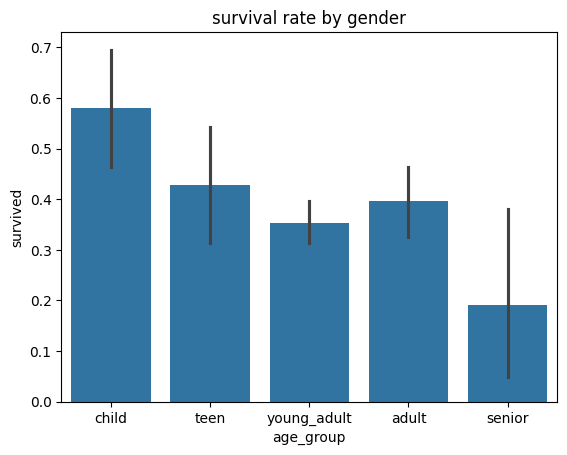

In [19]:
sns.barplot(x='age_group', y='survived', data=df)
plt.title('survival rate by gender')
plt.show()

### 🎟️ Survival Based on Passenger Class

Analyzing how ticket class influenced survival chances.

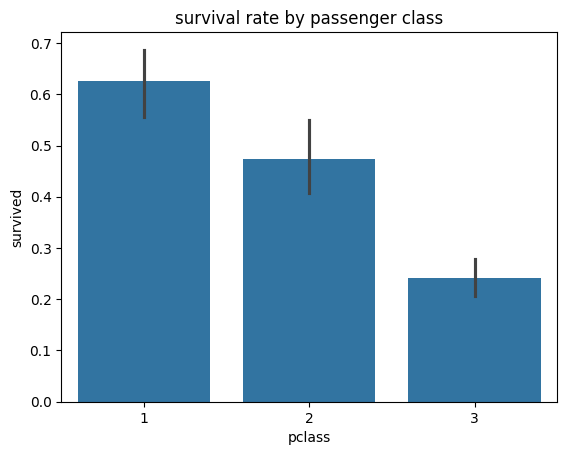

In [20]:
sns.barplot(x='pclass', y='survived', data=df)
plt.title('survival rate by passenger class')
plt.show()

### 📊 Age Distribution of Passengers

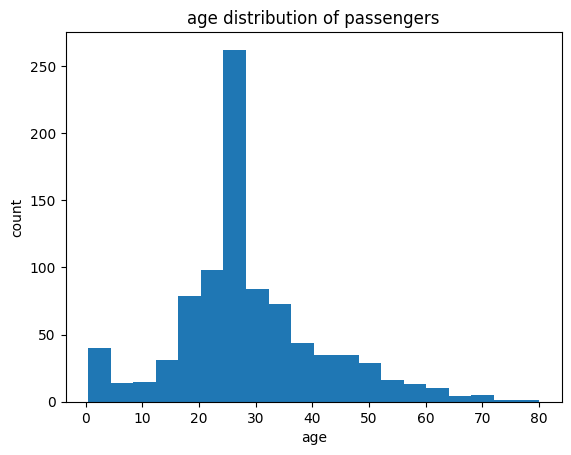

In [21]:
plt.hist(df['age'], bins=20)
plt.title('age distribution of passengers')
plt.xlabel('age')
plt.ylabel('count')
plt.show()

## 🔥 Correlation Analysis

Understanding relationships between numerical variables.

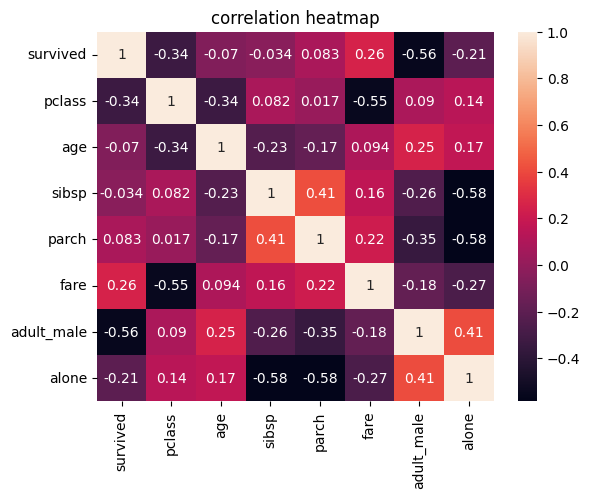

In [22]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('correlation heatmap')
plt.show()

## 💡 Key Insights

- Female passengers had a significantly higher survival rate than males
- Passengers in 1st class had the highest survival chances
- 3rd class passengers had the lowest survival rate
- Children showed relatively better survival chances
- Age and socio-economic status played an important role in survival

## 🧾 Conclusion

This analysis shows that survival on the Titanic was influenced by multiple factors such as gender, passenger class, and age.

The project demonstrates how data analysis and visualization can uncover meaningful insights from raw data.

This task helped in understanding:
- Data cleaning techniques
- Exploratory data analysis (EDA)
- Data visualization
- Drawing conclusions from data